In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/student-perfirmance")

#print("Path to dataset files:", path)
print("Path:", path)
print("Contenuto:", os.listdir(path))

name = "StudentPerformanceFactors.csv"
file_path = os.path.join(path,name)
print(file_path)
df = pd.read_csv(file_path)

Path: C:\Users\andre\.cache\kagglehub\datasets\ayeshasiddiqa123\student-perfirmance\versions\1
Contenuto: ['StudentPerformanceFactors.csv']
C:\Users\andre\.cache\kagglehub\datasets\ayeshasiddiqa123\student-perfirmance\versions\1\StudentPerformanceFactors.csv


In [22]:
df.shape

(6607, 20)

In [8]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [20]:

# Target
y = df["Exam_Score"]
X = df.drop(columns=["Exam_Score"])

# Ordinali (definisci ordine)
ordinal_mappings = {
    "Parental_Involvement": ["Low", "Medium", "High"],
    "Access_to_Resources": ["Low", "Medium", "High"],
    "Motivation_Level": ["Low", "Medium", "High"],
    "Family_Income": ["Low", "Medium", "High"],
    "Teacher_Quality": ["Low", "Medium", "High"],
    "Parental_Education_Level": ["High School", "College", "Postgraduate"],
    "Distance_from_Home": ["Near", "Moderate", "Far"]
}

# Applica encoding ordinale
for col, order in ordinal_mappings.items():
    X[col] = pd.Categorical(X[col], categories=order, ordered=True).codes

# Nominali → One-hot
nominal_cols = [
    "Internet_Access", "School_Type", "Gender",
    "Extracurricular_Activities", "Learning_Disabilities", "Peer_Influence"
]

# Trasformatore
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="error"), nominal_cols)
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()

# Converti in DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

X_processed_df.head()

,onehot__Internet_Access_No,onehot__Internet_Access_Yes,onehot__School_Type_Private,onehot__School_Type_Public,onehot__Gender_Female,onehot__Gender_Male,onehot__Extracurricular_Activities_No,onehot__Extracurricular_Activities_Yes,onehot__Learning_Disabilities_No,onehot__Learning_Disabilities_Yes,...,remainder__Access_to_Resources,remainder__Sleep_Hours,remainder__Previous_Scores,remainder__Motivation_Level,remainder__Tutoring_Sessions,remainder__Family_Income,remainder__Teacher_Quality,remainder__Physical_Activity,remainder__Parental_Education_Level,remainder__Distance_from_Home
0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,2.0,7.0,73.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0
1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,8.0,59.0,0.0,2.0,1.0,1.0,4.0,1.0,1.0
2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,7.0,91.0,1.0,2.0,1.0,1.0,4.0,2.0,0.0
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,8.0,98.0,1.0,1.0,1.0,1.0,4.0,0.0,1.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,6.0,65.0,1.0,3.0,1.0,2.0,4.0,1.0,0.0


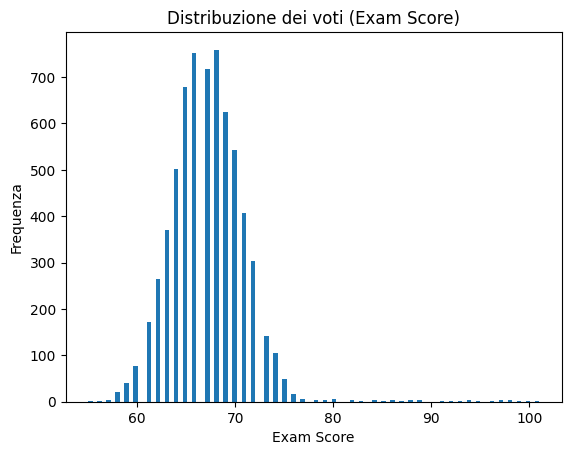

In [16]:
import matplotlib.pyplot as plt

plt.hist(df["Exam_Score"], bins=100)
plt.xlabel("Exam Score")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei voti (Exam Score)")

plt.show()

In [21]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Trasforma in DataFrame con nomi
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X_processed, columns=feature_names)

mi = mutual_info_regression(X_df, y)

mi_series = pd.Series(mi, index=feature_names)
mi_series = mi_series.sort_values(ascending=False)

print(mi_series)

remainder__Attendance                     0.314219
remainder__Hours_Studied                  0.149856
remainder__Access_to_Resources            0.031264
remainder__Previous_Scores                0.022509
onehot__Extracurricular_Activities_No     0.016347
remainder__Parental_Involvement           0.012366
onehot__Peer_Influence_Negative           0.010918
remainder__Motivation_Level               0.010374
onehot__Internet_Access_No                0.009942
remainder__Teacher_Quality                0.009832
onehot__School_Type_Private               0.008842
remainder__Parental_Education_Level       0.007957
remainder__Tutoring_Sessions              0.007463
remainder__Family_Income                  0.007390
onehot__Learning_Disabilities_No          0.005176
onehot__Gender_Male                       0.004587
onehot__Learning_Disabilities_Yes         0.003056
onehot__School_Type_Public                0.002995
onehot__Extracurricular_Activities_Yes    0.002490
onehot__Internet_Access_Yes    